In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

In [9]:
"""Script de entrenamiento para modelos de clasificación PET."""

import os
import sys

import torch
from matplotlib import pyplot as plt
from torch import nn
from torchvision import models

# Importar módulos propios
from data.dataset import get_data_loaders
from utils.config_utils import load_config

# Añadir directorios al path
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))

In [10]:
config_path = "configs/resnet18_2d_adni_cnad_server.yaml"

# Cargar configuración
config = load_config(config_path)

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Usando dispositivo: {device}")

# Obtener parámetros del modelo
model_config = config.get("model", {})
# model_name = model_config.get("name", "resnet18").lower()
# dimension = model_config.get("dimension", "2d").lower()

# Crear directorio para el experimento
# exp_base_dir = config.get("experiment", {}).get("base_dir", "./experiments")
# dataset_name = config.get("data", {}).get("dataset_name", "ADNI")
classes = config.get("data", {}).get("classes", "CN_AD")
# exp_name = config.get("experiment", {}).get("name", None)

# Crear modelo
num_classes = len(classes.split("_"))
model_config["num_classes"] = num_classes

# Obtener data loaders
train_loader, val_loader, test_loader = get_data_loaders(config)

Usando dispositivo: cuda
Configuración de clases: ['CN', 'AD'] (2 clases)
CSV cargado. Filas: 983
2D
Modo: train, Selección de cortes: middle
Clase(s): 2 (CN, AD)
Output size: [224, 224], Canales: 3
Usando umbralizado de Otsu para máscara cerebral
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'CN', 'AD']


Cargando dataset:   0%|          | 4/983 [00:00<00:57, 17.13it/s]

Cargando imagen: ./data/NIFTIs/Archivo/converted_niftis/018_S_4349.nii.gz
Dimensiones de la imagen: (128, 128, 35, 6)
Header de la imagen: <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'')
dim_info        : 0
dim             : [  4 128 128  35   6   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1.   2.   2.   4.25 0.   1.   1.   1.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'FreeSurfer Feb  5 2025')
aux_file        : np.bytes_(b'')
qform_

Cargando dataset:   9%|▉         | 93/983 [00:27<04:25,  3.35it/s]


KeyboardInterrupt: 

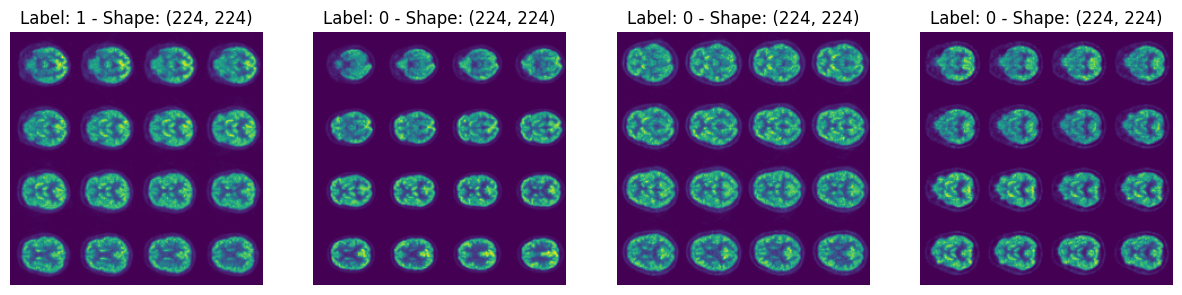

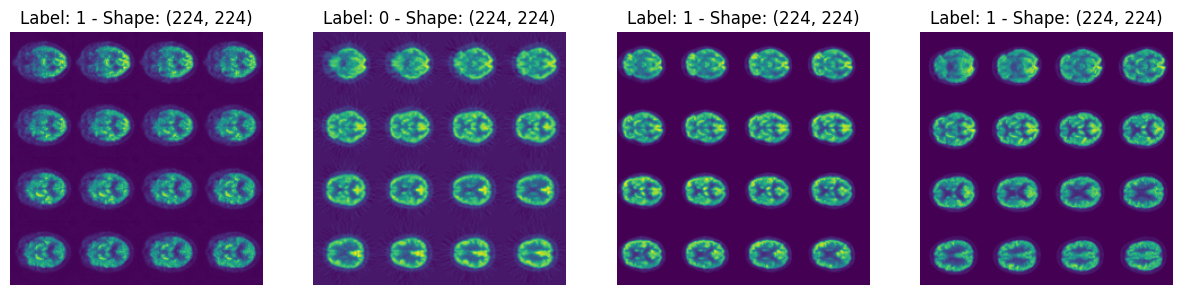

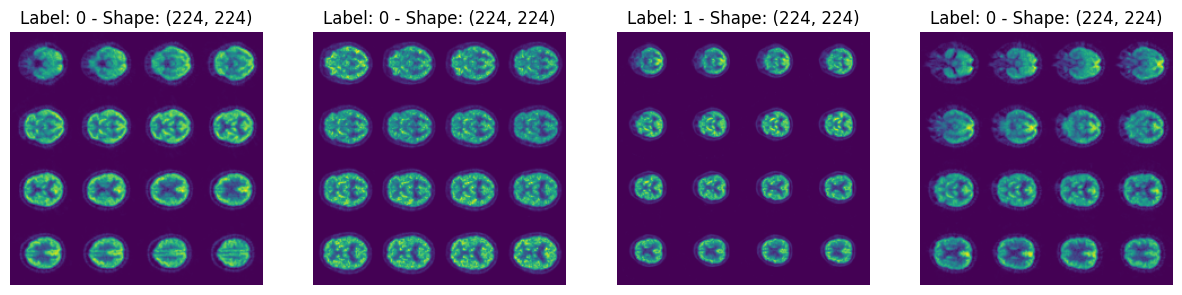

In [5]:
# Plot images from the training set
def plot_images(data_loader, num_images=4):
    images = []
    labels = []

    # Collect images and labels from the data loader
    for i, (image, label) in enumerate(data_loader):
        if i >= num_images:
            break
        images.append(image)
        labels.append(label)
    images = torch.stack(images)
    labels = torch.stack(labels)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        img = images[i].squeeze().cpu().numpy()
        # normalize the image to [0, 1] range for better visualization
        img = (img - img.min()) / (img.max() - img.min())
        img = img * 255
        if img.ndim == 4:
            img = img[0]
        img = img[0]

        axes[i].imshow(img, cmap="viridis")
        axes[i].set_title(f"Label: {torch.argmax(labels[i]).item()} - Shape: {img.shape}")
        axes[i].axis("off")
    plt.show()


# Plot images from the training set
plot_images(train_loader)
plot_images(val_loader)
plot_images(test_loader)

## ResNet

## InceptionNet

In [ ]:
config

{'experiment': {'base_dir': './experiments', 'name': 'baseline'},
 'wandb': {'enabled': True,
  'project': 'PET',
  'entity': 'pardo',
  'name': 'resnet18_2d_adni_cnad',
  'tags': ['resnet18', '2d', 'adni', 'pet', 'alzheimer', 'cn_ad'],
  'notes': 'Entrenamiento de ResNet-18 2D para clasificación de Alzheimer con imágenes PET',
  'group': 'resnet18_2d',
  'job_type': 'train',
  'watch_model': True,
  'watch_freq': 100,
  'log_frequency': 1},
 'model': {'name': 'resnet18',
  'dimension': '2d',
  'pretrained': True,
  'feature_extract': False,
  'dropout_rate': 0.0,
  'num_classes': 2},
 'data': {'dataset_name': 'ADNI',
  'classes': 'CN_AD',
  'dimension': '2d',
  'data_dir': './data/NIFTIs/Archivo/converted_niftis/',
  'train_csv': './data/metadata/adni_train.csv',
  'val_csv': './data/metadata/adni_val.csv',
  'test_csv': './data/metadata/adni_test.csv',
  'batch_size': 4,
  'num_workers': 1,
  'slice_selection': 'middle',
  'num_slices': 16,
  'resample': True,
  'output_size': [224, 

In [ ]:
config["data"]["output_size"] = (299, 299)

train_loader, val_loader, test_loader = get_data_loaders(config)

Configuración de clases: ['CN', 'AD'] (2 clases)
CSV cargado. Filas: 983
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'CN', 'AD']


Cargando dataset:   0%|          | 4/983 [00:00<00:52, 18.54it/s]

Cargando imagen: ./data/NIFTIs/Archivo/converted_niftis/018_S_4349.nii.gz
Dimensiones de la imagen: (128, 128, 35, 6)
Header de la imagen: <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'')
dim_info        : 0
dim             : [  4 128 128  35   6   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1.   2.   2.   4.25 0.   1.   1.   1.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'FreeSurfer Feb  5 2025')
aux_file        : np.bytes_(b'')
qform_

Cargando dataset: 100%|██████████| 983/983 [03:36<00:00,  4.53it/s]


Total de muestras cargadas: 544 de 544 sujetos

Distribución de clases:
  - CN: 272 muestras (50.0%)
  - AD: 272 muestras (50.0%)
CSV cargado. Filas: 112
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'AD', 'CN']


...

Total de muestras cargadas: 57 de 57 sujetos

Distribución de clases:
  - CN: 35 muestras (61.4%)
  - AD: 22 muestras (38.6%)
CSV cargado. Filas: 112
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'CN', 'AD']


Cargando dataset:   4%|▍         | 5/112 [00:00<00:02, 38.65it/s]

Cargando imagen: ./data/NIFTIs/Archivo/converted_niftis/012_S_5121.nii.gz
Dimensiones de la imagen: (128, 128, 35, 6)
Header de la imagen: <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'')
dim_info        : 0
dim             : [  4 128 128  35   6   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [  1.     2.     2.     4.25 300.     1.     1.     1.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'FreeSurfer Feb  5 2025')
aux_file        : np.by

Cargando dataset: 100%|██████████| 112/112 [00:21<00:00,  5.12it/s]

Total de muestras cargadas: 57 de 57 sujetos

Distribución de clases:
  - CN: 34 muestras (59.6%)
  - AD: 23 muestras (40.4%)


In [ ]:
# Entrenar modelo
model = models.inception_v3(weights="IMAGENET1K_V1")  # Usar pesos preentrenados
# model = models.resnet18(weights=None)  # No usar pesos preentrenados
# model.fc = nn.Linear(model.fc.in_features, num_classes)

model.dropout = nn.Dropout(p=0.6)  # Añadir dropout
model.fc = nn.Sequential(nn.Linear(model.fc.in_features, num_classes), nn.Softmax(dim=1))

model = model.to(device)

In [ ]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

In [ ]:
model.eval()
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    print(f"Labels: {labels}")
    print(f"Output: {outputs}")

    _, predicted = torch.max(outputs, 1)
    print(f"Predicted: {predicted}")
    print(f"ArgMax: {torch.argmax(outputs, dim=1)}")

    # Calcular matriz de confusión
    cm = confusion_matrix(
        torch.argmax(labels, dim=1).cpu().numpy(),
        torch.argmax(outputs, dim=1).cpu().numpy(),
        labels=list(range(num_classes)),
    )

    print(f"Confusion Matrix:\n{cm}")

    break

Labels: tensor([[1., 0.]], device='cuda:0')
Output: tensor([[0.4156, 0.5844]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Predicted: tensor([1], device='cuda:0')
ArgMax: tensor([1], device='cuda:0')
Confusion Matrix:
[[0 1]
 [0 0]]


Epoch 100/100: 100%|██████████| 100/100 [14:18<00:00,  8.58s/it, train_accuracy=0.994, train_loss=0.322, val_accuracy=0.789, val_loss=0.499]


Best Validation Accuracy: 0.8596


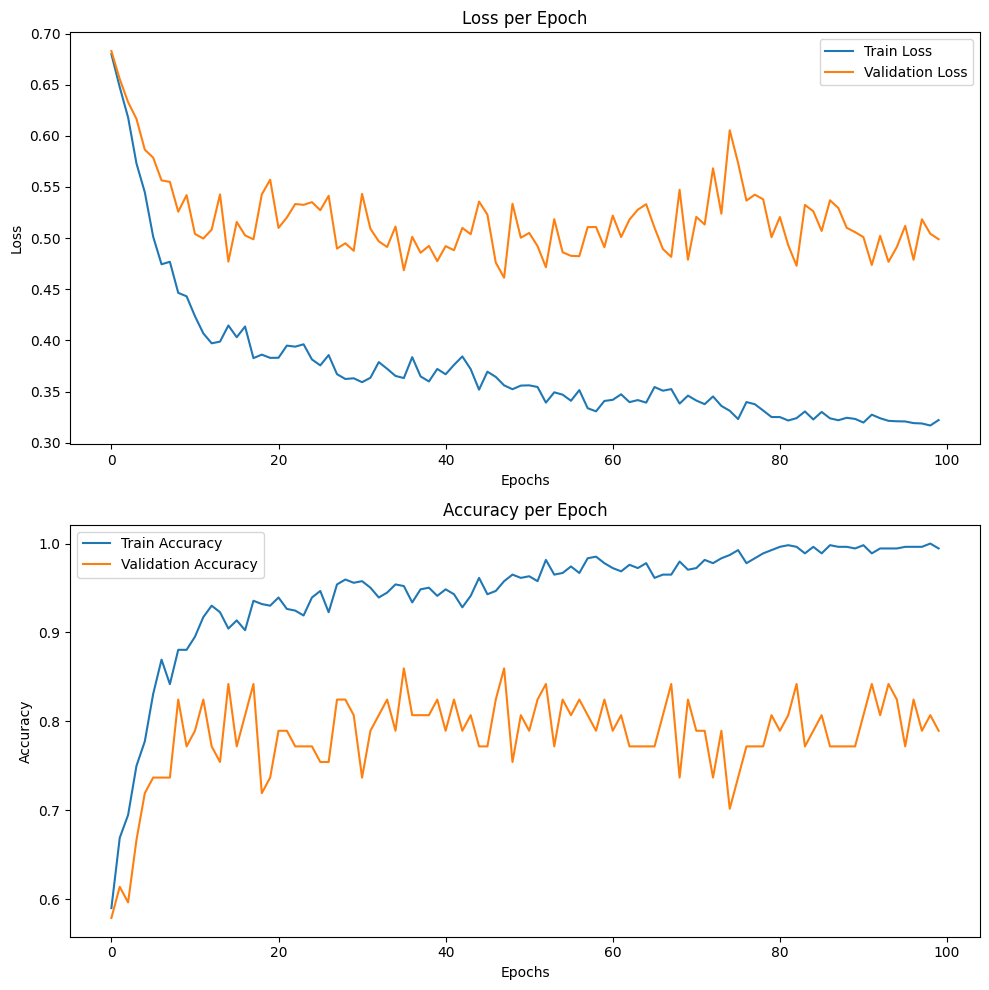

In [ ]:
model.train()

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 100

epoch_iterator = tqdm(range(epochs), desc="Training Progress")
for epoch in epoch_iterator:
    epoch_iterator.set_description(f"Epoch {epoch + 1}/{epochs}")

    corrects = 0
    total = 0

    batch_losses = []

    for batch in train_loader:
        # Entrenamiento
        model.train()
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, aux_output = model(inputs)
        loss_value = loss(outputs, labels)
        loss_value.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        trues = labels.argmax(dim=1)
        batch_corrects = (preds == trues).sum().item()

        corrects += batch_corrects
        total += labels.size(0)

        batch_losses.append(loss_value.item())

    train_loss = sum(batch_losses) / len(batch_losses)
    train_accuracy = corrects / len(train_loader.dataset)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    # Valid
    val_loss = 0.0
    val_corrects = 0
    val_total = 0

    for val_batch in val_loader:
        val_inputs, val_labels = val_batch
        val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

        with torch.no_grad():
            outputs = model(val_inputs)
            v_loss = loss(outputs, val_labels)
            preds = outputs.argmax(dim=1)
            trues = val_labels.argmax(dim=1)
            v_corrects = (preds == trues).sum().item()

        val_corrects += v_corrects
        val_total += val_labels.size(0)
        val_loss += v_loss.item() * val_labels.size(0)

    val_loss /= val_total
    val_accuracy = val_corrects / val_total

    # save checkpoint
    if val_accuracy > max(val_accuracies, default=0):
        if not os.path.exists("checkpoints"):
            os.makedirs("checkpoints")
        torch.save(model.state_dict(), os.path.join(os.getcwd(), "checkpoints", "best_model.pth"))

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # print(
    #     f"Epoch {epoch + 1}/{epochs}, Loss: {loss_value.item()}, Accuracy: {accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}"
    # )
    epoch_iterator.set_postfix(
        train_loss=train_loss,
        train_accuracy=train_accuracy,
        val_loss=val_loss,
        val_accuracy=val_accuracy,
    )

print(f"Best Validation Accuracy: {max(val_accuracies):.4f}")

# Plotear resultados
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
axs[0].plot(train_losses, label="Train Loss")
axs[0].plot(val_losses, label="Validation Loss")
axs[0].set_title("Loss per Epoch")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(train_accuracies, label="Train Accuracy")
axs[1].plot(val_accuracies, label="Validation Accuracy")
axs[1].set_title("Accuracy per Epoch")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
plt.tight_layout()

plt.savefig("training_results.png")

In [ ]:
best_model = models.inception_v3(weights="IMAGENET1K_V1")  # Usar pesos preentrenados

best_model.dropout = nn.Dropout(p=0.6)  # Añadir dropout
best_model.fc = nn.Sequential(nn.Linear(best_model.fc.in_features, num_classes), nn.Softmax(dim=1))

best_model = best_model.to(device)
# Cargar el mejor modelo guardado
best_model.load_state_dict(torch.load(os.path.join(os.getcwd(), "checkpoints", "best_model.pth")))
# Evaluar el mejor modelo en el conjunto de prueba
# best_model = model

best_model.eval()
with torch.no_grad():
    test_loss = 0.0
    test_corrects = 0
    test_total = 0
    for test_batch in test_loader:
        test_inputs, test_labels = test_batch
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

        outputs = best_model(test_inputs)
        t_loss = loss(outputs, test_labels)
        preds = outputs.argmax(dim=1)
        trues = test_labels.argmax(dim=1)
        t_corrects = (preds == trues).sum().item()
        test_corrects += t_corrects
        test_total += test_labels.size(0)
        test_loss += t_loss.item() * test_labels.size(0)

    test_loss /= test_total
    test_accuracy = test_corrects / test_total
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6286, Test Accuracy: 0.6667


In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes, set_name="Test"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - " + set_name)
    plt.show()

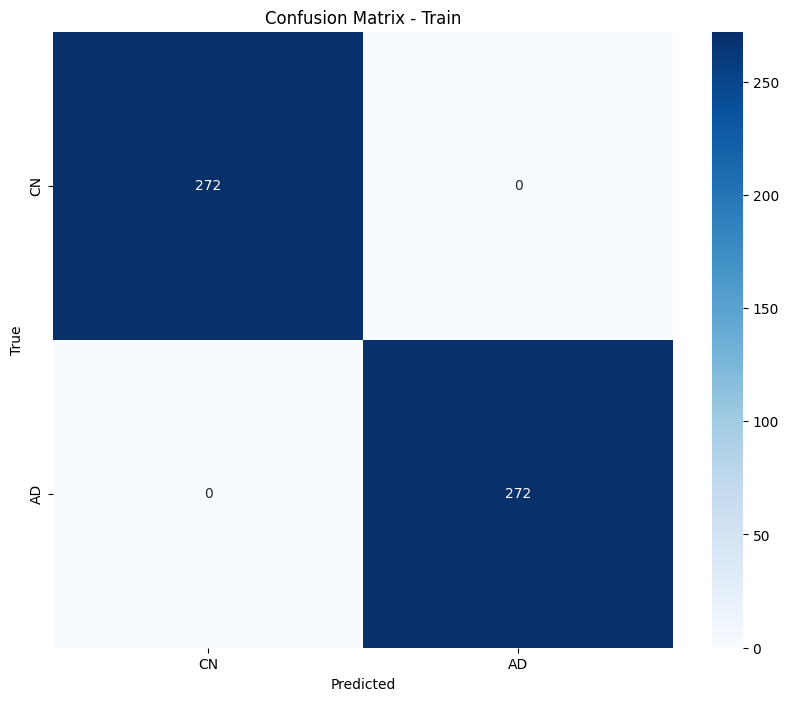

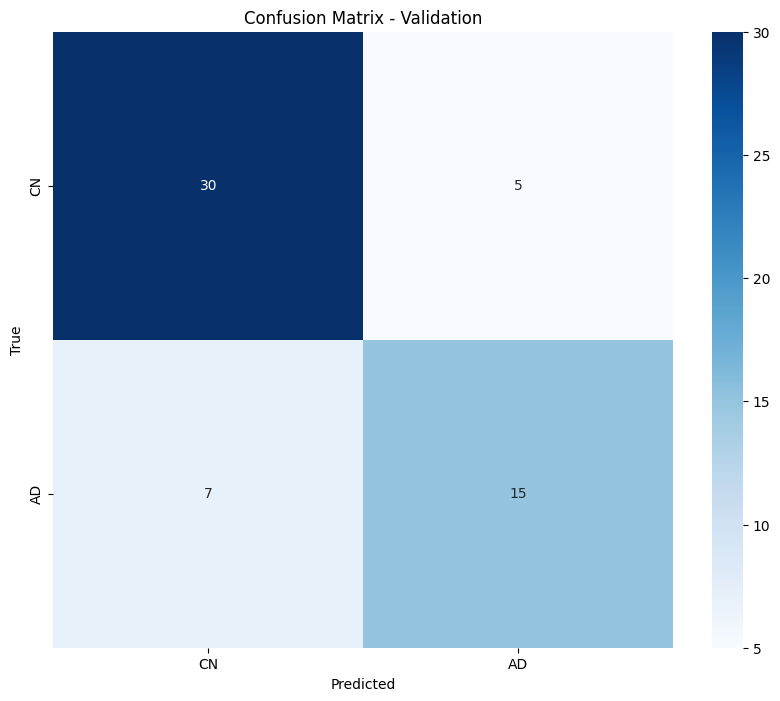

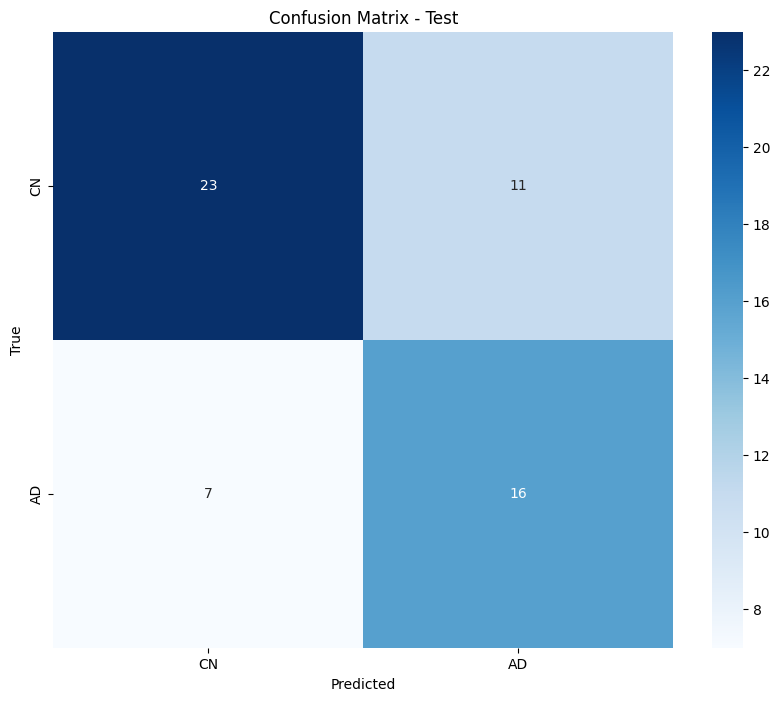

In [ ]:
# Confusion matrix
# train
y_true = []
y_pred = []
for train_batch in train_loader:
    train_inputs, train_labels = train_batch
    train_inputs, train_labels = train_inputs.to(device), train_labels.to(device)

    with torch.no_grad():
        outputs = model(train_inputs)
        pred = outputs.argmax(dim=1)
        true = train_labels.argmax(dim=1) if train_labels.dim() > 1 else train_labels
        y_true.extend(true.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
# Plotear matriz de confusión
plot_confusion_matrix(y_true, y_pred, classes.split("_"), set_name="Train")

# val
y_true = []
y_pred = []
for val_batch in val_loader:
    val_inputs, val_labels = val_batch
    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

    with torch.no_grad():
        outputs = model(val_inputs)
        pred = outputs.argmax(dim=1)
        true = val_labels.argmax(dim=1) if val_labels.dim() > 1 else val_labels
        y_true.extend(true.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
# Plotear matriz de confusión
plot_confusion_matrix(y_true, y_pred, classes.split("_"), set_name="Validation")

# Obtener predicciones del conjunto de prueba
y_true = []
y_pred = []
for test_batch in test_loader:
    test_inputs, test_labels = test_batch
    test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

    with torch.no_grad():
        outputs = model(test_inputs)
        pred = outputs.argmax(dim=1)
        true = test_labels.argmax(dim=1) if test_labels.dim() > 1 else test_labels
        y_true.extend(true.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
# Plotear matriz de confusión
plot_confusion_matrix(y_true, y_pred, classes.split("_"), set_name="Test")

## Vision Transformer (ViT)

In [ ]:
from transformers import ViTImageProcessor

model_name = "google/vit-large-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
processor

from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

# Get configurations from ViT processor
image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size["height"]

# Normalizes the image pixels by subtracting the mean and dividing by the std from the pretrained model configurations
normalize = Normalize(mean=image_mean, std=image_std)

# Compose: Combines a series of image transformations into one pipeline.
train_transforms = Compose(
    [
        RandomResizedCrop(size),
        RandomHorizontalFlip(),
        ToTensor(),
        normalize,
    ]
)
val_transforms = Compose(
    [
        Resize(size),
        CenterCrop(size),
        ToTensor(),
        normalize,
    ]
)
test_transforms = Compose(
    [
        Resize(size),
        CenterCrop(size),
        ToTensor(),
        normalize,
    ]
)

In [ ]:
# Vision Transformer
from torchvision.models import vit_b_16, vit_b_32

# model = vit_b_16(weights="IMAGENET1K_V1")  # Usar pesos preentrenados
model = vit_b_32(weights="IMAGENET1K_V1")  # Usar pesos preentrenados

# model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
model.heads.head = nn.Sequential(
    nn.Linear(model.heads.head.in_features, num_classes), nn.Softmax(dim=1)
)

model = model.to(device)

loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

model.eval()
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    print(f"Labels: {labels}")
    print(f"Output: {outputs}")

    _, predicted = torch.max(outputs, 1)
    print(f"Predicted: {predicted}")
    print(f"ArgMax: {torch.argmax(outputs, dim=1)}")

    # Calcular matriz de confusión
    cm = confusion_matrix(
        torch.argmax(labels, dim=1).cpu().numpy(),
        torch.argmax(outputs, dim=1).cpu().numpy(),
        labels=list(range(num_classes)),
    )

    print(f"Confusion Matrix:\n{cm}")

    break

Labels: tensor([[1., 0.]], device='cuda:0')
Output: tensor([[0.6389, 0.3611]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Predicted: tensor([0], device='cuda:0')
ArgMax: tensor([0], device='cuda:0')
Confusion Matrix:
[[1 0]
 [0 0]]


In [ ]:
model

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
model.train()
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
epochs = 100
epoch_iterator = tqdm(range(epochs), desc="Training Progress")
for epoch in epoch_iterator:
    epoch_iterator.set_description(f"Epoch {epoch + 1}/{epochs}")

    corrects = 0
    total = 0

    batch_losses = []

    for batch in train_loader:
        # Entrenamiento
        model.train()
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss_value = loss(outputs, labels)
        loss_value.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        trues = labels.argmax(dim=1)
        batch_corrects = (preds == trues).sum().item()

        corrects += batch_corrects
        total += labels.size(0)

        batch_losses.append(loss_value.item())

    train_loss = sum(batch_losses) / len(batch_losses)
    train_accuracy = corrects / len(train_loader.dataset)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    # Valid
    val_loss = 0.0
    val_corrects = 0
    val_total = 0

    for val_batch in val_loader:
        val_inputs, val_labels = val_batch
        val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

        with torch.no_grad():
            outputs = model(val_inputs)
            v_loss = loss(outputs, val_labels)
            preds = outputs.argmax(dim=1)
            trues = val_labels.argmax(dim=1)
            v_corrects = (preds == trues).sum().item()

        val_corrects += v_corrects
        val_total += val_labels.size(0)
        val_loss += v_loss.item() * val_labels.size(0)

    val_loss /= val_total
    val_accuracy = val_corrects / val_total

    # save checkpoint
    if val_accuracy > max(val_accuracies, default=0):
        if not os.path.exists("checkpoints"):
            os.makedirs("checkpoints")
        torch.save(
            model.state_dict(),
            os.path.join(os.getcwd(), "checkpoints", "best_model_vit.pth"),
        )

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    epoch_iterator.set_postfix(
        train_loss=train_loss,
        train_accuracy=train_accuracy,
        val_loss=val_loss,
        val_accuracy=val_accuracy,
    )
print(f"Best Validation Accuracy: {max(val_accuracies):.4f}")

Epoch 100/100: 100%|██████████| 100/100 [11:07<00:00,  6.67s/it, train_accuracy=0.994, train_loss=0.319, val_accuracy=0.719, val_loss=0.606]

Best Validation Accuracy: 0.7895


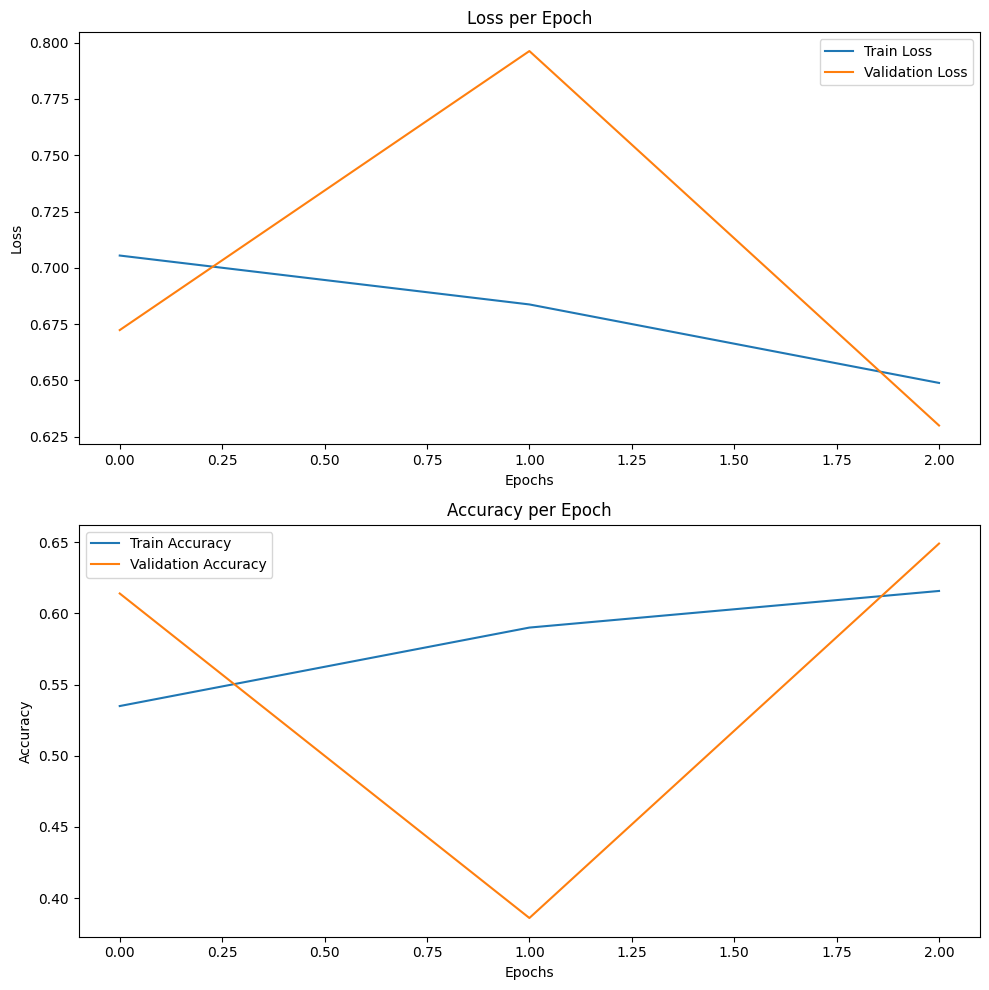

In [ ]:
# Plotear resultados
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
axs[0].plot(train_losses, label="Train Loss")
axs[0].plot(val_losses, label="Validation Loss")
axs[0].set_title("Loss per Epoch")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[1].plot(train_accuracies, label="Train Accuracy")
axs[1].plot(val_accuracies, label="Validation Accuracy")
axs[1].set_title("Accuracy per Epoch")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
plt.tight_layout()

Test Loss: 0.6739, Test Accuracy: 0.6140


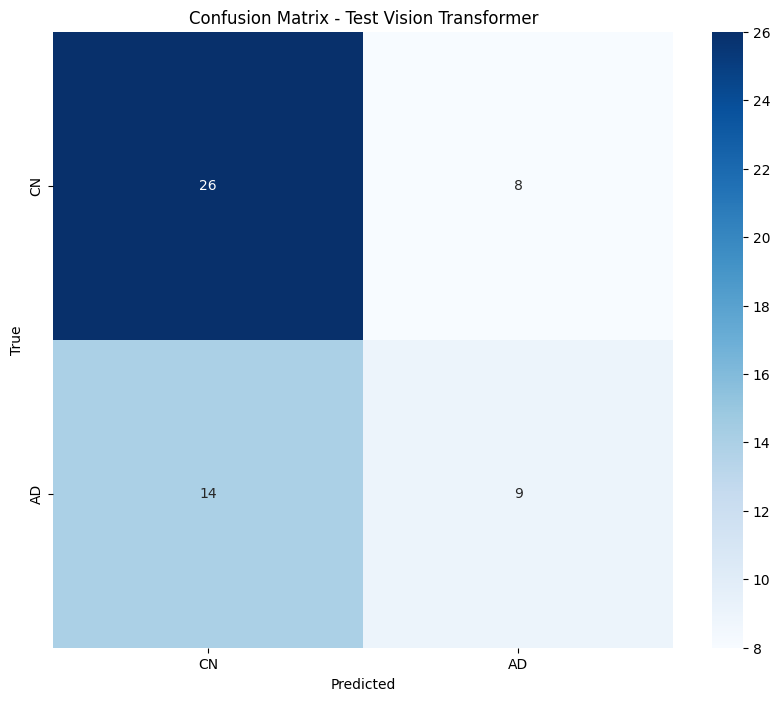

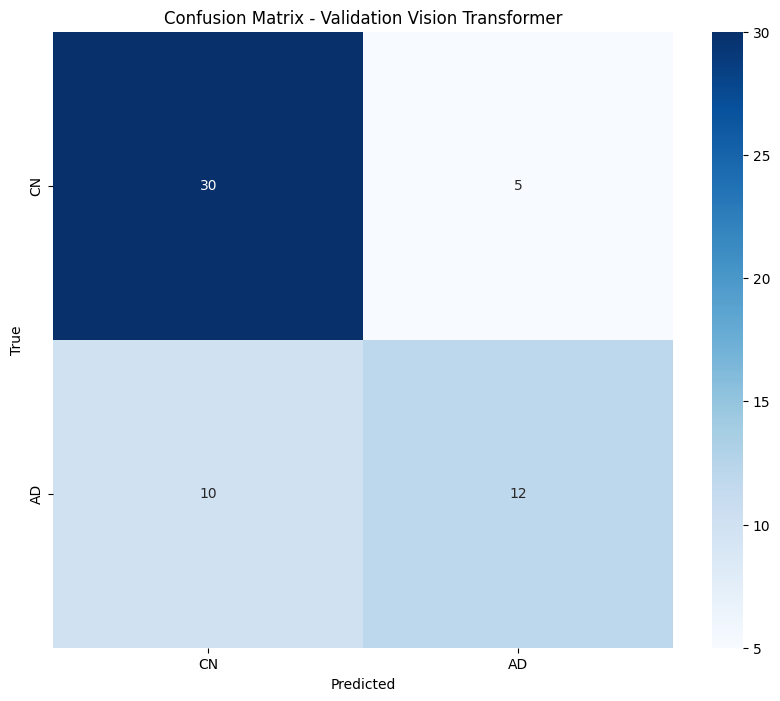

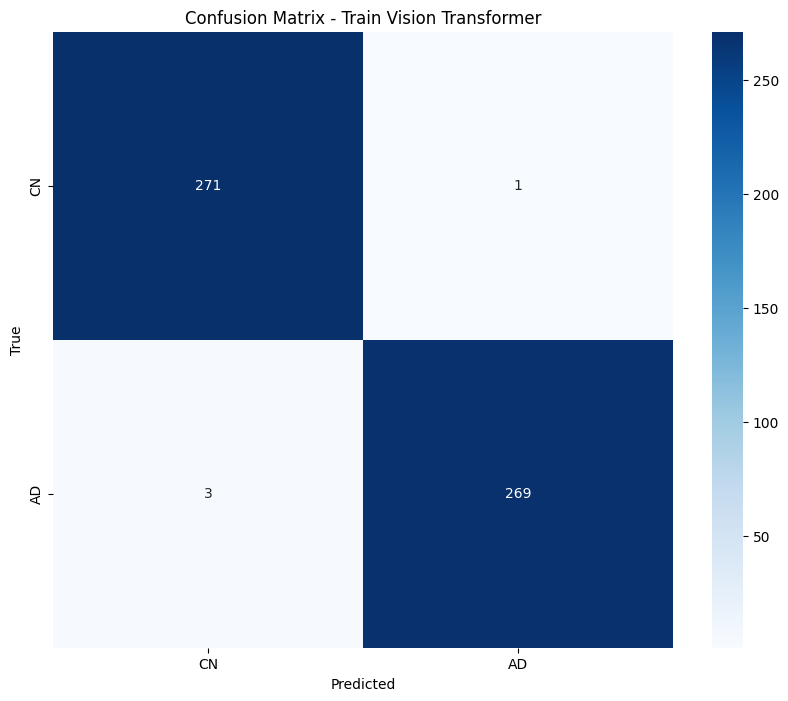

In [ ]:
best_model = vit_b_16(weights="IMAGENET1K_V1")  # Usar pesos preentrenados
best_model.heads.head = nn.Sequential(
    nn.Linear(best_model.heads.head.in_features, num_classes), nn.Softmax(dim=1)
)

best_model = best_model.to(device)
# Cargar el mejor modelo guardado
best_model.load_state_dict(
    torch.load(os.path.join(os.getcwd(), "checkpoints", "best_model_vit.pth"))
)

# Evaluar el mejor modelo en el conjunto de prueba
best_model.eval()
with torch.no_grad():
    test_loss = 0.0
    test_corrects = 0
    test_total = 0
    for test_batch in test_loader:
        test_inputs, test_labels = test_batch
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

        outputs = best_model(test_inputs)
        t_loss = loss(outputs, test_labels)
        preds = outputs.argmax(dim=1)
        trues = test_labels.argmax(dim=1) if test_labels.dim() > 1 else test_labels
        t_corrects = (preds == trues).sum().item()
        test_corrects += t_corrects
        test_total += test_labels.size(0)
        test_loss += t_loss.item() * test_labels.size(0)

    test_loss /= test_total
    test_accuracy = test_corrects / test_total
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
# Confusion matrix for Vision Transformer
y_true = []
y_pred = []
for test_batch in test_loader:
    test_inputs, test_labels = test_batch
    test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

    with torch.no_grad():
        outputs = best_model(test_inputs)
        pred = outputs.argmax(dim=1)
        true = test_labels.argmax(dim=1) if test_labels.dim() > 1 else test_labels
        y_true.extend(true.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Plotear matriz de confusión
plot_confusion_matrix(y_true, y_pred, classes.split("_"), set_name="Test Vision Transformer")

# val
y_true = []
y_pred = []
for val_batch in val_loader:
    val_inputs, val_labels = val_batch
    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

    with torch.no_grad():
        outputs = best_model(val_inputs)
        pred = outputs.argmax(dim=1)
        true = val_labels.argmax(dim=1) if val_labels.dim() > 1 else val_labels
        y_true.extend(true.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
# Plotear matriz de confusión
plot_confusion_matrix(y_true, y_pred, classes.split("_"), set_name="Validation Vision Transformer")

# train
y_true = []
y_pred = []
for train_batch in train_loader:
    train_inputs, train_labels = train_batch
    train_inputs, train_labels = train_inputs.to(device), train_labels.to(device)

    with torch.no_grad():
        outputs = best_model(train_inputs)
        pred = outputs.argmax(dim=1)
        true = train_labels.argmax(dim=1) if train_labels.dim() > 1 else train_labels
        y_true.extend(true.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Plotear matriz de confusión
plot_confusion_matrix(y_true, y_pred, classes.split("_"), set_name="Train Vision Transformer")

# 3D

## ResNet3D-18

In [6]:
import torch
import torch.nn as nn
from huggingface_hub import hf_hub_download

/home/ipardo/.conda/envs/pet/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [7]:
from torchvision.models.video import r3d_18

In [11]:
# Install required packages if not already installed:
# !pip install torch torchvision huggingface_hub


# Download the pretrained MedicalNet ResNet18 weights from Hugging Face
model_path = hf_hub_download(
    repo_id="TencentMedicalNet/MedicalNet-Resnet18", filename="resnet_18_23dataset.pth"
)

# Instantiate the model
model = r3d_18()
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features, num_classes
    ),  # Adjust the output layer for the number of classes
    nn.Softmax(dim=1),  # Apply softmax to the output
)

# Load the pretrained weights
state_dict = torch.load(model_path, map_location="cpu")
# If the state_dict has a 'state_dict' key (from some checkpoints), use it
if "state_dict" in state_dict:
    state_dict = {
        k.replace("module.", "").replace("model.", ""): v
        for k, v in state_dict["state_dict"].items()
    }
model.load_state_dict(state_dict, strict=False)

model

VideoResNet(
  (stem): BasicStem(
    (0): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Sequential(
        (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (conv2): Sequential(
        (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Sequential(
        (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1):